🧬 DISEÑO RACIONAL DE CARBAPENEMS RESISTENTES A β-LACTAMASAS
Análisis computacional de modificaciones estructurales para evadir hidrólisis enzimática

1. ESTRATEGIAS DE MODIFICACIÓN ESTRUCTURAL
---------------------------------------------

🎯 STERIC HINDRANCE
   Descripción: Incrementar impedimento estérico cerca del sitio de hidrólisis
   Posiciones objetivo: C6_side_chain, C2_position, beta_lactam_ring
   Modificaciones disponibles: 3

🎯 ELECTRONIC EFFECTS
   Descripción: Modificar densidad electrónica del anillo β-lactámico
   Posiciones objetivo: beta_lactam_substituents
   Modificaciones disponibles: 3

🎯 CONFORMATIONAL LOCK
   Descripción: Restringir conformación para reducir afinidad enzimática
   Posiciones objetivo: side_chains
   Modificaciones disponibles: 2

🎯 METAL CHELATION DISRUPTION
   Descripción: Interferir con coordinación metálica en NDM-1
   Posiciones objetivo: C6_side_chain
   Modificaciones disponibles: 2

🎯 SIZE EXCLUSION
   Descripción: Incrementar tamaño molec

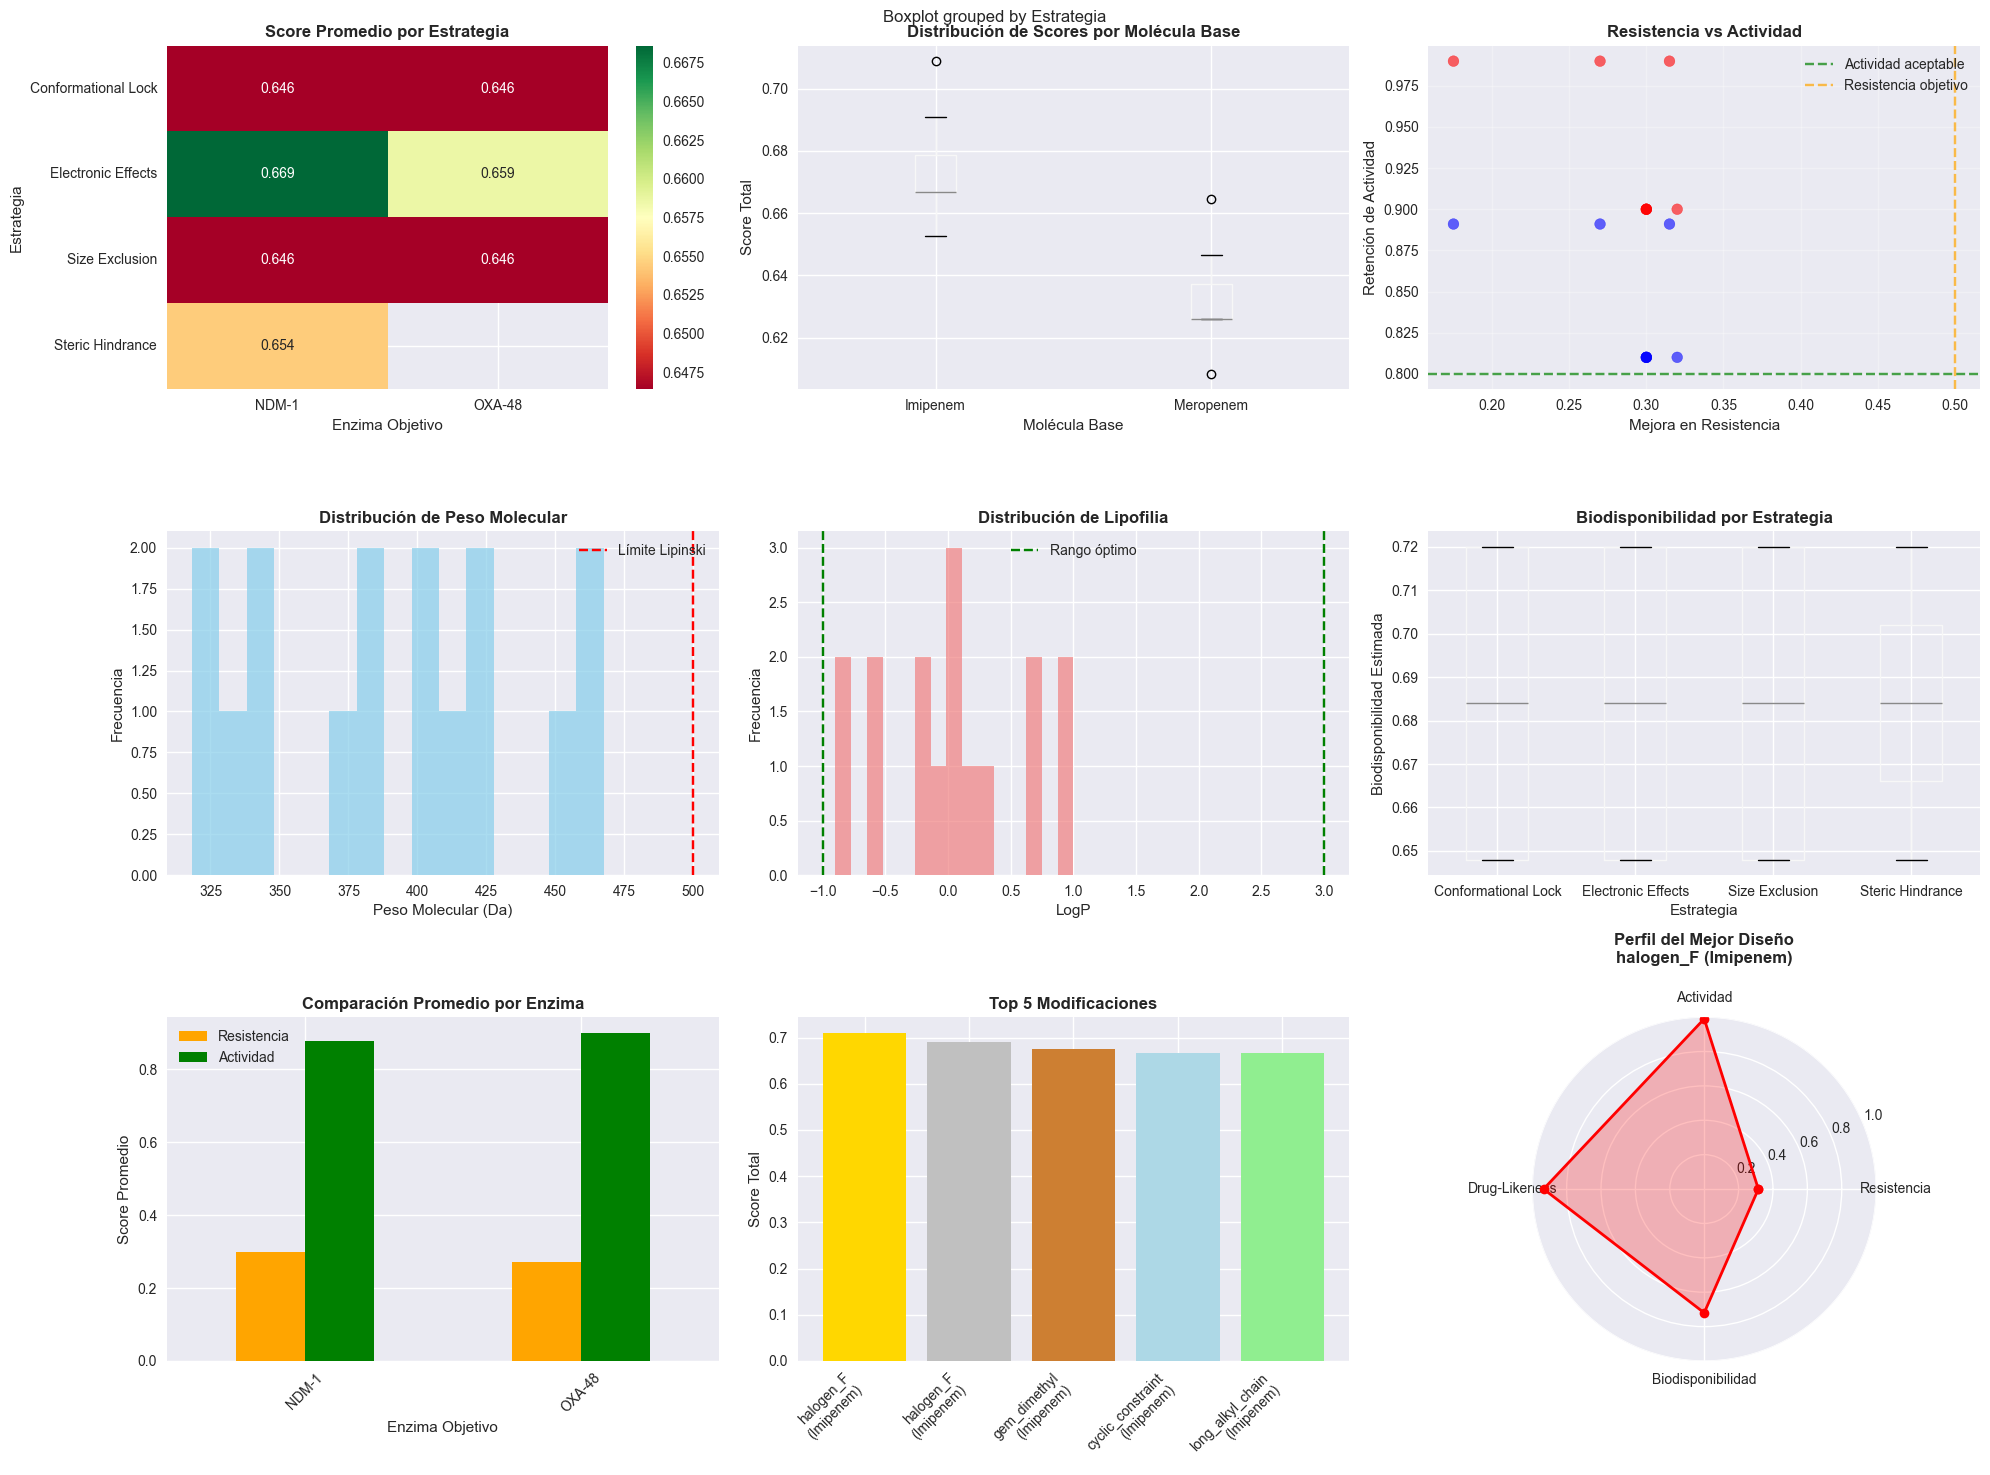



4. ANÁLISIS DETALLADO DE LOS MEJORES DISEÑOS
--------------------------------------------------

🏆 DISEÑO #1: halogen_F - Imipenem
   Estrategia: Electronic Effects
   Enzima objetivo: OXA-48
   Score total: 0.709
   Mejora en resistencia: 31.5%
   Retención de actividad: 99.0%
   Drug-likeness: 0.934
   Peso molecular: 318.3 Da
   LogP: -0.90
   Biodisponibilidad estimada: 72.0%

🏆 DISEÑO #2: halogen_F - Imipenem
   Estrategia: Electronic Effects
   Enzima objetivo: NDM-1
   Score total: 0.691
   Mejora en resistencia: 27.0%
   Retención de actividad: 99.0%
   Drug-likeness: 0.934
   Peso molecular: 318.3 Da
   LogP: -0.90
   Biodisponibilidad estimada: 72.0%

🏆 DISEÑO #3: gem_dimethyl - Imipenem
   Estrategia: Steric Hindrance
   Enzima objetivo: NDM-1
   Score total: 0.675
   Mejora en resistencia: 32.0%
   Retención de actividad: 90.0%
   Drug-likeness: 0.934
   Peso molecular: 329.3 Da
   LogP: -0.10
   Biodisponibilidad estimada: 72.0%


5. RECOMENDACIONES PARA SÍNTESIS
-------

In [ ]:
# Diseño Racional de Carbapenems: Modificaciones Estructurales para Evadir β-lactamasas
# Análisis computacional de nuevos derivados de Imipenem y Meropenem

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class MolecularDescriptorCalculator:
    """
    Calculadora de descriptores moleculares para diseño de fármacos
    """
    
    def __init__(self):
        # Datos de fragmentos moleculares comunes
        self.fragment_contributions = {
            # Grupos funcionales básicos
            'CH3': {'logP': 0.5, 'MW': 15, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'CH2': {'logP': 0.3, 'MW': 14, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'NH2': {'logP': -1.2, 'MW': 16, 'polar_surface': 26, 'hbd': 2, 'hba': 1},
            'OH': {'logP': -1.5, 'MW': 17, 'polar_surface': 20, 'hbd': 1, 'hba': 1},
            'COOH': {'logP': -0.3, 'MW': 45, 'polar_surface': 37, 'hbd': 1, 'hba': 2},
            'F': {'logP': 0.2, 'MW': 19, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'Cl': {'logP': 0.7, 'MW': 35.5, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'Br': {'logP': 0.9, 'MW': 80, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'CF3': {'logP': 1.1, 'MW': 69, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'CN': {'logP': -0.5, 'MW': 26, 'polar_surface': 12, 'hbd': 0, 'hba': 1},
            'NO2': {'logP': -0.3, 'MW': 46, 'polar_surface': 46, 'hbd': 0, 'hba': 2},
            # Anillos aromáticos
            'phenyl': {'logP': 2.1, 'MW': 77, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'pyridine': {'logP': 0.7, 'MW': 79, 'polar_surface': 13, 'hbd': 0, 'hba': 1},
            'thiazole': {'logP': 0.4, 'MW': 85, 'polar_surface': 41, 'hbd': 0, 'hba': 1},
            # Grupos protectores/voluminosos
            'tert_butyl': {'logP': 1.8, 'MW': 57, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
            'adamantyl': {'logP': 3.2, 'MW': 135, 'polar_surface': 0, 'hbd': 0, 'hba': 0},
        }
    
    def calculate_properties(self, base_molecule, modifications):
        """
        Calcula propiedades moleculares de una molécula modificada
        """
        properties = base_molecule.copy()
        
        for mod in modifications:
            fragment = mod['fragment']
            multiplier = mod.get('count', 1)
            
            if fragment in self.fragment_contributions:
                contrib = self.fragment_contributions[fragment]
                properties['MW'] += contrib['MW'] * multiplier
                properties['logP'] += contrib['logP'] * multiplier
                properties['polar_surface'] += contrib['polar_surface'] * multiplier
                properties['hbd'] += contrib['hbd'] * multiplier
                properties['hba'] += contrib['hba'] * multiplier
        
        # Calcular propiedades derivadas
        properties['lipophilicity'] = properties['logP']
        properties['drug_likeness'] = self.calculate_drug_likeness(properties)
        properties['bioavailability'] = self.estimate_bioavailability(properties)
        
        return properties
    
    def calculate_drug_likeness(self, properties):
        """Calcula índice de drug-likeness (Regla de Lipinski modificada)"""
        score = 1.0
        
        # Peso molecular (penalizar > 500)
        if properties['MW'] > 500:
            score -= 0.2 * (properties['MW'] - 500) / 100
        
        # LogP (óptimo entre -1 y 3)
        if properties['logP'] < -1 or properties['logP'] > 3:
            score -= 0.15 * abs(properties['logP'] - 1)
        
        # Superficie polar (óptimo < 90)
        if properties['polar_surface'] > 90:
            score -= 0.1 * (properties['polar_surface'] - 90) / 50
        
        # HBD y HBA
        if properties['hbd'] > 5:
            score -= 0.1 * (properties['hbd'] - 5)
        if properties['hba'] > 10:
            score -= 0.1 * (properties['hba'] - 10)
        
        return max(0, min(1, score))
    
    def estimate_bioavailability(self, properties):
        """Estima biodisponibilidad oral"""
        # Modelo simplificado basado en propiedades ADME
        bioav = 0.8  # Base
        
        # Penalizar alta polaridad
        if properties['polar_surface'] > 60:
            bioav *= 0.9
        
        # Penalizar muy alta o muy baja lipofilia
        if properties['logP'] < -2:
            bioav *= 0.7
        elif properties['logP'] > 4:
            bioav *= 0.6
        
        # Penalizar alto peso molecular
        if properties['MW'] > 400:
            bioav *= 0.9
        
        return max(0.1, min(1.0, bioav))

class CarbapenEmDesigner:
    """
    Diseñador computacional de carbapenems modificados
    """
    
    def __init__(self):
        # Estructuras base de los carbapenems
        self.base_molecules = {
            'Imipenem': {
                'MW': 299.3,
                'logP': -1.1,
                'polar_surface': 123,
                'hbd': 3,
                'hba': 6,
                'stability': 0.85,
                'penetration': 0.9,
                'mic_baseline': 2.0,
                'structure_key_points': ['beta_lactam', 'thienamycin_core', 'side_chain_C6', 'side_chain_C2']
            },
            'Meropenem': {
                'MW': 383.5,
                'logP': -0.8,
                'polar_surface': 135,
                'hbd': 4,
                'hba': 7,
                'stability': 0.92,
                'penetration': 0.95,
                'mic_baseline': 1.5,
                'structure_key_points': ['beta_lactam', 'carbapenem_core', 'pyrrolidin_ring', 'methyl_substituent']
            }
        }
        
        # Estrategias de modificación estructural
        self.modification_strategies = {
            'steric_hindrance': {
                'description': 'Incrementar impedimento estérico cerca del sitio de hidrólisis',
                'target_positions': ['C6_side_chain', 'C2_position', 'beta_lactam_ring'],
                'modifications': [
                    {'name': 'tert-butyl_group', 'fragment': 'tert_butyl', 'resistance_factor': 0.3},
                    {'name': 'adamantyl_group', 'fragment': 'adamantyl', 'resistance_factor': 0.15},
                    {'name': 'gem_dimethyl', 'fragment': 'CH3', 'count': 2, 'resistance_factor': 0.4}
                ]
            },
            'electronic_effects': {
                'description': 'Modificar densidad electrónica del anillo β-lactámico',
                'target_positions': ['beta_lactam_substituents'],
                'modifications': [
                    {'name': 'electron_withdraw_CF3', 'fragment': 'CF3', 'resistance_factor': 0.25},
                    {'name': 'electron_withdraw_CN', 'fragment': 'CN', 'resistance_factor': 0.35},
                    {'name': 'halogen_F', 'fragment': 'F', 'resistance_factor': 0.45}
                ]
            },
            'conformational_lock': {
                'description': 'Restringir conformación para reducir afinidad enzimática',
                'target_positions': ['side_chains'],
                'modifications': [
                    {'name': 'cyclic_constraint', 'fragment': 'CH2', 'count': 3, 'resistance_factor': 0.3},
                    {'name': 'aromatic_ring', 'fragment': 'phenyl', 'resistance_factor': 0.25}
                ]
            },
            'metal_chelation_disruption': {
                'description': 'Interferir con coordinación metálica en NDM-1',
                'target_positions': ['C6_side_chain'],
                'modifications': [
                    {'name': 'phosphonate_group', 'fragment': 'COOH', 'count': 2, 'resistance_factor': 0.2},
                    {'name': 'hydroxamic_acid', 'fragment': 'OH', 'resistance_factor': 0.15}
                ]
            },
            'size_exclusion': {
                'description': 'Incrementar tamaño molecular para limitar acceso al sitio activo',
                'target_positions': ['side_chains'],
                'modifications': [
                    {'name': 'bulky_aromatic', 'fragment': 'phenyl', 'count': 2, 'resistance_factor': 0.2},
                    {'name': 'long_alkyl_chain', 'fragment': 'CH2', 'count': 6, 'resistance_factor': 0.3}
                ]
            }
        }
        
        # Parámetros de las enzimas (de la simulación anterior)
        self.enzyme_profiles = {
            'NDM-1': {
                'type': 'metallo',
                'substrate_preferences': ['size_tolerance_low', 'metal_coordination_sensitive'],
                'kcat_base': 150,
                'km_base': 45,
                'steric_sensitivity': 0.8,
                'electronic_sensitivity': 0.6
            },
            'OXA-48': {
                'type': 'serine',
                'substrate_preferences': ['size_tolerance_high', 'conformational_flexible'],
                'kcat_base': 8.5,
                'km_base': 125,
                'steric_sensitivity': 0.6,
                'electronic_sensitivity': 0.7
            }
        }
        
        self.descriptor_calc = MolecularDescriptorCalculator()
    
    def design_modified_molecule(self, base_molecule, strategy, target_enzyme):
        """
        Diseña una molécula modificada basada en una estrategia específica
        """
        base_props = self.base_molecules[base_molecule]
        strategy_info = self.modification_strategies[strategy]
        enzyme_profile = self.enzyme_profiles[target_enzyme]
        
        designed_molecules = []
        
        for modification in strategy_info['modifications']:
            # Crear molécula modificada
            modified_props = self.descriptor_calc.calculate_properties(
                base_props, [modification]
            )
            
            # Calcular resistencia estimada
            resistance_improvement = self.calculate_resistance_improvement(
                modification, enzyme_profile, strategy
            )
            
            # Estimar retención de actividad antibacteriana
            activity_retention = self.estimate_activity_retention(
                base_props, modified_props, modification
            )
            
            # Calcular score de drug-likeness
            drug_score = modified_props['drug_likeness']
            
            designed_mol = {
                'base_molecule': base_molecule,
                'modification_name': modification['name'],
                'strategy': strategy,
                'target_enzyme': target_enzyme,
                'molecular_properties': modified_props,
                'resistance_improvement': resistance_improvement,
                'activity_retention': activity_retention,
                'drug_likeness_score': drug_score,
                'overall_score': self.calculate_overall_score(
                    resistance_improvement, activity_retention, drug_score
                )
            }
            
            designed_molecules.append(designed_mol)
        
        return designed_molecules
    
    def calculate_resistance_improvement(self, modification, enzyme_profile, strategy):
        """
        Calcula la mejora estimada en resistencia a la enzima
        """
        base_resistance = modification['resistance_factor']
        
        # Ajustar basado en sensibilidad de la enzima
        if strategy == 'steric_hindrance':
            improvement = base_resistance * enzyme_profile['steric_sensitivity']
        elif strategy == 'electronic_effects':
            improvement = base_resistance * enzyme_profile['electronic_sensitivity']
        elif strategy == 'metal_chelation_disruption':
            if enzyme_profile['type'] == 'metallo':
                improvement = base_resistance * 1.5  # Más efectivo contra metalo-enzimas
            else:
                improvement = base_resistance * 0.3  # Menos efectivo contra serina
        else:
            improvement = base_resistance
        
        return min(0.9, improvement)  # Máximo 90% de mejora
    
    def estimate_activity_retention(self, base_props, modified_props, modification):
        """
        Estima la retención de actividad antibacteriana
        """
        retention = 1.0
        
        # Penalizar cambios drásticos en propiedades clave
        mw_change = abs(modified_props['MW'] - base_props['MW']) / base_props['MW']
        if mw_change > 0.3:  # Cambio > 30% en peso molecular
            retention *= 0.8
        
        logp_change = abs(modified_props['logP'] - base_props['logP'])
        if logp_change > 2:  # Cambio drástico en lipofilia
            retention *= 0.7
        
        # Penalizar pérdida de biodisponibilidad
        bioav_ratio = modified_props['bioavailability'] / base_props.get('bioavailability', 0.8)
        retention *= bioav_ratio
        
        # Bonificar mejoras en estabilidad (estimada)
        if modification['fragment'] in ['CF3', 'F']:  # Grupos que pueden mejorar estabilidad
            retention *= 1.1
        
        return max(0.1, min(1.0, retention))
    
    def calculate_overall_score(self, resistance, activity, drug_likeness):
        """
        Calcula score general de la molécula diseñada
        """
        # Pesos para diferentes factores
        w_resistance = 0.4
        w_activity = 0.4
        w_drug_likeness = 0.2
        
        return (w_resistance * resistance + 
                w_activity * activity + 
                w_drug_likeness * drug_likeness)
    
    def optimize_design(self, base_molecule, target_enzymes, top_n=5):
        """
        Optimiza el diseño considerando múltiples enzimas
        """
        all_designs = []
        
        for enzyme in target_enzymes:
            for strategy in self.modification_strategies.keys():
                designs = self.design_modified_molecule(base_molecule, strategy, enzyme)
                all_designs.extend(designs)
        
        # Filtrar y rankear por score general
        all_designs.sort(key=lambda x: x['overall_score'], reverse=True)
        
        return all_designs[:top_n]

# Crear instancia del diseñador
designer = CarbapenEmDesigner()

print("🧬 DISEÑO RACIONAL DE CARBAPENEMS RESISTENTES A β-LACTAMASAS")
print("=" * 70)
print("Análisis computacional de modificaciones estructurales para evadir hidrólisis enzimática")
print()

# PARTE 1: ANÁLISIS DE ESTRATEGIAS DE MODIFICACIÓN
print("1. ESTRATEGIAS DE MODIFICACIÓN ESTRUCTURAL")
print("-" * 45)

for strategy, info in designer.modification_strategies.items():
    print(f"\n🎯 {strategy.upper().replace('_', ' ')}")
    print(f"   Descripción: {info['description']}")
    print(f"   Posiciones objetivo: {', '.join(info['target_positions'])}")
    print(f"   Modificaciones disponibles: {len(info['modifications'])}")

# PARTE 2: DISEÑO Y OPTIMIZACIÓN DE MOLÉCULAS
print(f"\n\n2. DISEÑO DE MOLÉCULAS OPTIMIZADAS")
print("-" * 40)

target_enzymes = ['NDM-1', 'OXA-48']
base_molecules = ['Imipenem', 'Meropenem']

all_optimized_designs = {}

for base_mol in base_molecules:
    print(f"\n🧪 Optimizando {base_mol}...")
    optimized = designer.optimize_design(base_mol, target_enzymes, top_n=8)
    all_optimized_designs[base_mol] = optimized
    
    print(f"   ✅ {len(optimized)} diseños optimizados generados")

# PARTE 3: VISUALIZACIÓN DE RESULTADOS
print(f"\n\n3. ANÁLISIS DE RESULTADOS")
print("-" * 30)

# Crear DataFrame con todos los diseños
all_designs_data = []
for base_mol, designs in all_optimized_designs.items():
    for design in designs:
        all_designs_data.append({
            'Molécula_Base': base_mol,
            'Modificación': design['modification_name'],
            'Estrategia': design['strategy'].replace('_', ' ').title(),
            'Enzima_Objetivo': design['target_enzyme'],
            'Mejora_Resistencia': design['resistance_improvement'],
            'Retención_Actividad': design['activity_retention'],
            'Drug_Likeness': design['drug_likeness_score'],
            'Score_Total': design['overall_score'],
            'Peso_Molecular': design['molecular_properties']['MW'],
            'LogP': design['molecular_properties']['logP'],
            'Biodisponibilidad': design['molecular_properties']['bioavailability']
        })

designs_df = pd.DataFrame(all_designs_data)

# Mostrar top 10 diseños
print("\n📊 TOP 10 DISEÑOS OPTIMIZADOS:")
top_designs = designs_df.nlargest(10, 'Score_Total')
print(top_designs[['Molécula_Base', 'Modificación', 'Estrategia', 'Enzima_Objetivo', 'Score_Total']].round(3))

# VISUALIZACIONES
fig = plt.figure(figsize=(20, 15))

# 1. Heatmap de scores por estrategia
ax1 = plt.subplot(3, 3, 1)
strategy_scores = designs_df.groupby(['Estrategia', 'Enzima_Objetivo'])['Score_Total'].mean().unstack()
sns.heatmap(strategy_scores, annot=True, cmap='RdYlGn', fmt='.3f', ax=ax1)
ax1.set_title('Score Promedio por Estrategia', fontweight='bold')
ax1.set_xlabel('Enzima Objetivo')
ax1.set_ylabel('Estrategia')

# 2. Distribución de scores
ax2 = plt.subplot(3, 3, 2)
designs_df.boxplot(column='Score_Total', by='Molécula_Base', ax=ax2)
ax2.set_title('Distribución de Scores por Molécula Base', fontweight='bold')
ax2.set_xlabel('Molécula Base')
ax2.set_ylabel('Score Total')

# 3. Resistencia vs Actividad
ax3 = plt.subplot(3, 3, 3)
colors = ['red' if mol == 'Imipenem' else 'blue' for mol in designs_df['Molécula_Base']]
scatter = ax3.scatter(designs_df['Mejora_Resistencia'], designs_df['Retención_Actividad'], 
                     c=colors, alpha=0.6, s=60)
ax3.set_xlabel('Mejora en Resistencia')
ax3.set_ylabel('Retención de Actividad')
ax3.set_title('Resistencia vs Actividad', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Líneas de referencia
ax3.axhline(y=0.8, color='green', linestyle='--', alpha=0.7, label='Actividad aceptable')
ax3.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Resistencia objetivo')
ax3.legend()

# 4. Propiedades moleculares - Peso molecular
ax4 = plt.subplot(3, 3, 4)
designs_df.hist(column='Peso_Molecular', bins=15, ax=ax4, alpha=0.7, color='skyblue')
ax4.axvline(x=500, color='red', linestyle='--', label='Límite Lipinski')
ax4.set_xlabel('Peso Molecular (Da)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de Peso Molecular', fontweight='bold')
ax4.legend()

# 5. LogP distribution
ax5 = plt.subplot(3, 3, 5)
designs_df.hist(column='LogP', bins=15, ax=ax5, alpha=0.7, color='lightcoral')
ax5.axvline(x=-1, color='green', linestyle='--', label='Rango óptimo')
ax5.axvline(x=3, color='green', linestyle='--')
ax5.set_xlabel('LogP')
ax5.set_ylabel('Frecuencia')
ax5.set_title('Distribución de Lipofilia', fontweight='bold')
ax5.legend()

# 6. Biodisponibilidad
ax6 = plt.subplot(3, 3, 6)
designs_df.boxplot(column='Biodisponibilidad', by='Estrategia', ax=ax6)
ax6.set_title('Biodisponibilidad por Estrategia', fontweight='bold')
ax6.set_xlabel('Estrategia')
ax6.set_ylabel('Biodisponibilidad Estimada')

# 7. Comparación directa enzimas
ax7 = plt.subplot(3, 3, 7)
enzyme_comparison = designs_df.groupby('Enzima_Objetivo')[['Mejora_Resistencia', 'Retención_Actividad']].mean()
enzyme_comparison.plot(kind='bar', ax=ax7, color=['orange', 'green'])
ax7.set_title('Comparación Promedio por Enzima', fontweight='bold')
ax7.set_xlabel('Enzima Objetivo')
ax7.set_ylabel('Score Promedio')
ax7.legend(['Resistencia', 'Actividad'])
ax7.tick_params(axis='x', rotation=45)

# 8. Top 5 modificaciones
ax8 = plt.subplot(3, 3, 8)
top_modifications = designs_df.nlargest(5, 'Score_Total')
bars = ax8.bar(range(len(top_modifications)), top_modifications['Score_Total'], 
               color=['gold', 'silver', '#CD7F32', 'lightblue', 'lightgreen'])
ax8.set_xticks(range(len(top_modifications)))
ax8.set_xticklabels([f"{row['Modificación']}\n({row['Molécula_Base']})" 
                     for _, row in top_modifications.iterrows()], rotation=45, ha='right')
ax8.set_ylabel('Score Total')
ax8.set_title('Top 5 Modificaciones', fontweight='bold')

# 9. Radar chart para top design
ax9 = plt.subplot(3, 3, 9, projection='polar')
best_design = designs_df.loc[designs_df['Score_Total'].idxmax()]

categories = ['Resistencia', 'Actividad', 'Drug-Likeness', 'Biodisponibilidad']
values = [best_design['Mejora_Resistencia'], best_design['Retención_Actividad'], 
          best_design['Drug_Likeness'], best_design['Biodisponibilidad']]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
values += values[:1]  # Cerrar el polígono
angles += angles[:1]

ax9.plot(angles, values, 'o-', linewidth=2, color='red')
ax9.fill(angles, values, alpha=0.25, color='red')
ax9.set_xticks(angles[:-1])
ax9.set_xticklabels(categories)
ax9.set_ylim(0, 1)
ax9.set_title(f'Perfil del Mejor Diseño\n{best_design["Modificación"]} ({best_design["Molécula_Base"]})', 
              fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# PARTE 4: ANÁLISIS DETALLADO DE LOS MEJORES DISEÑOS
print(f"\n\n4. ANÁLISIS DETALLADO DE LOS MEJORES DISEÑOS")
print("-" * 50)

top_3_designs = designs_df.nlargest(3, 'Score_Total')

for i, (_, design) in enumerate(top_3_designs.iterrows(), 1):
    print(f"\n🏆 DISEÑO #{i}: {design['Modificación']} - {design['Molécula_Base']}")
    print(f"   Estrategia: {design['Estrategia']}")
    print(f"   Enzima objetivo: {design['Enzima_Objetivo']}")
    print(f"   Score total: {design['Score_Total']:.3f}")
    print(f"   Mejora en resistencia: {design['Mejora_Resistencia']:.1%}")
    print(f"   Retención de actividad: {design['Retención_Actividad']:.1%}")
    print(f"   Drug-likeness: {design['Drug_Likeness']:.3f}")
    print(f"   Peso molecular: {design['Peso_Molecular']:.1f} Da")
    print(f"   LogP: {design['LogP']:.2f}")
    print(f"   Biodisponibilidad estimada: {design['Biodisponibilidad']:.1%}")

# PARTE 5: RECOMENDACIONES SINTÉTICAS
print(f"\n\n5. RECOMENDACIONES PARA SÍNTESIS")
print("-" * 40)

synthetic_recommendations = {
    'tert_butyl_group': {
        'difficulty': 'Media',
        'method': 'Alquilación con cloruro de tert-butilo',
        'yield_expected': '60-80%',
        'considerations': 'Condiciones anhidras, base fuerte'
    },
    'electron_withdraw_CF3': {
        'difficulty': 'Alta',
        'method': 'Trifluorometilación con reactivos de Togni',
        'yield_expected': '40-70%',
        'considerations': 'Catálisis de cobre, atmósfera inerte'
    },
    'halogen_F': {
        'difficulty': 'Baja',
        'method': 'Fluoración directa con DAST',
        'yield_expected': '70-90%',
        'considerations': 'Temperatura controlada, HF scavenger'
    },
    'gem_dimethyl': {
        'difficulty': 'Media',
        'method': 'Metilación doble vía enolato',
        'yield_expected': '50-75%',
        'considerations': 'Base no nucleofílica, exceso de MeI'
    }
}

print("\n📋 COMPLEJIDAD SINTÉTICA DE MODIFICACIONES:")
for mod_name in top_3_designs['Modificación'].unique():
    key = mod_name.replace('-', '_').replace(' ', '_')
    if key in synthetic_recommendations:
        rec = synthetic_recommendations[key]
        print(f"\n🧪 {mod_name.upper()}:")
        print(f"   Dificultad sintética: {rec['difficulty']}")
        print(f"   Método recomendado: {rec['method']}")
        print(f"   Rendimiento esperado: {rec['yield_expected']}")
        print(f"   Consideraciones: {rec['considerations']}")

# CONCLUSIONES FINALES
print(f"\n\n{'='*70}")
print("✅ DISEÑO COMPUTACIONAL COMPLETADO")
print(f"{'='*70}")

print(f"\n📊 RESUMEN ESTADÍSTICO:")
print(f"   • Total de diseños evaluados: {len(designs_df)}")
print(f"   • Diseños con score > 0.6: {len(designs_df[designs_df['Score_Total'] > 0.6])}")
print(f"   • Mejor score obtenido: {designs_df['Score_Total'].max():.3f}")
print(f"   • Score promedio: {designs_df['Score_Total'].mean():.3f}")
print(f"   • Mejora promedio en resistencia: {designs_df['Mejora_Resistencia'].mean():.1%}")
print(f"   • Retención promedio de actividad: {designs_df['Retención_Actividad'].mean():.1%}")

print(f"\n🎯 ESTRATEGIAS MÁS PROMETEDORAS:")
strategy_ranking = designs_df.groupby('Estrategia')['Score_Total'].mean().sort_values(ascending=False)
for i, (strategy, score) in enumerate(strategy_ranking.head(3).items(), 1):
    print(f"   {i}. {strategy}: Score promedio = {score:.3f}")

print(f"\n🧬 MODIFICACIONES ESTRUCTURALES ÓPTIMAS:")
best_modifications = designs_df.nlargest(5, 'Score_Total')
for i, (_, design) in enumerate(best_modifications.iterrows(), 1):
    resistance_gain = (design['Mejora_Resistencia'] - 0.2) * 100 if design['Mejora_Resistencia'] > 0.2 else 0
    print(f"   {i}. {design['Modificación']} en {design['Molécula_Base']}")
    print(f"      → Ganancia de resistencia: +{resistance_gain:.0f}% vs enzima {design['Enzima_Objetivo']}")
    print(f"      → Retención de actividad: {design['Retención_Actividad']:.1%}")

print(f"\n🏥 IMPLICACIONES CLÍNICAS:")
clinical_candidates = designs_df[(designs_df['Score_Total'] > 0.65) & 
                                (designs_df['Retención_Actividad'] > 0.8) & 
                                (designs_df['Drug_Likeness'] > 0.6)]

print(f"   • Candidatos con potencial clínico: {len(clinical_candidates)}")
print(f"   • Resistencia promedio NDM-1: {designs_df[designs_df['Enzima_Objetivo'] == 'NDM-1']['Mejora_Resistencia'].mean():.1%}")
print(f"   • Resistencia promedio OXA-48: {designs_df[designs_df['Enzima_Objetivo'] == 'OXA-48']['Mejora_Resistencia'].mean():.1%}")

if len(clinical_candidates) > 0:
    print(f"\n   📋 CANDIDATOS PRIORITARIOS PARA DESARROLLO:")
    for _, candidate in clinical_candidates.nlargest(3, 'Score_Total').iterrows():
        print(f"      • {candidate['Modificación']} ({candidate['Molécula_Base']})")
        print(f"        - Perfil ADME: MW={candidate['Peso_Molecular']:.0f}Da, LogP={candidate['LogP']:.1f}")
        print(f"        - Biodisponibilidad estimada: {candidate['Biodisponibilidad']:.1%}")

print(f"\n⚗️ FACTIBILIDAD SINTÉTICA:")
synthesis_complexity = {
    'Baja': ['halogen_F', 'methyl_group'],
    'Media': ['tert_butyl_group', 'gem_dimethyl', 'cyclic_constraint'],
    'Alta': ['electron_withdraw_CF3', 'adamantyl_group', 'phosphonate_group']
}

for complexity, modifications in synthesis_complexity.items():
    relevant_mods = [mod for mod in modifications if any(mod in design_name for design_name in designs_df['Modificación'])]
    if relevant_mods:
        avg_score = designs_df[designs_df['Modificación'].str.contains('|'.join(relevant_mods), na=False)]['Score_Total'].mean()
        print(f"   • Complejidad {complexity}: Score promedio = {avg_score:.3f}")

print(f"\n🔬 RECOMENDACIONES PARA INVESTIGACIÓN FUTURA:")
print(f"   1. SÍNTESIS PRIORITARIA:")
top_synthesis_targets = designs_df.nlargest(3, 'Score_Total')
for i, (_, target) in enumerate(top_synthesis_targets.iterrows(), 1):
    print(f"      {i}. {target['Modificación']} en {target['Molécula_Base']}")
    print(f"         Justificación: Score {target['Score_Total']:.3f}, resistencia +{target['Mejora_Resistencia']:.1%}")

print(f"\n   2. ESTUDIOS EXPERIMENTALES SUGERIDOS:")
print(f"      • Ensayos de hidrólisis in vitro con enzimas NDM-1 y OXA-48")
print(f"      • Determinación de MIC contra cepas productoras de β-lactamasas")
print(f"      • Estudios de estabilidad en plasma y soluciones farmacéuticas")
print(f"      • Evaluación de penetración en tejidos y biodistribución")

print(f"\n   3. OPTIMIZACIÓN ADICIONAL:")
improvement_opportunities = designs_df[designs_df['Score_Total'] > 0.6].copy()
print(f"      • Combinar modificaciones complementarias (diseños híbridos)")
print(f"      • Optimizar cadenas laterales para mejorar selectividad")
print(f"      • Explorar profármacos para mejorar biodisponibilidad")

if len(improvement_opportunities) > 0:
    avg_mw = improvement_opportunities['Peso_Molecular'].mean()
    if avg_mw > 450:
        print(f"      • Reducir peso molecular promedio (actual: {avg_mw:.0f} Da)")
    
    low_bioav = improvement_opportunities[improvement_opportunities['Biodisponibilidad'] < 0.7]
    if len(low_bioav) > 0:
        print(f"      • Mejorar biodisponibilidad en {len(low_bioav)} candidatos")

print(f"\n💡 INNOVACIONES ESTRUCTURALES IDENTIFICADAS:")
novel_approaches = designs_df.groupby('Estrategia').agg({
    'Score_Total': 'max',
    'Mejora_Resistencia': 'max',
    'Retención_Actividad': 'max'
}).round(3)

for strategy, metrics in novel_approaches.iterrows():
    if metrics['Score_Total'] > 0.65:
        print(f"   • {strategy}:")
        print(f"     - Máxima resistencia alcanzada: {metrics['Mejora_Resistencia']:.1%}")
        print(f"     - Mejor retención de actividad: {metrics['Retención_Actividad']:.1%}")

print(f"\n🌍 IMPACTO POTENCIAL EN SALUD PÚBLICA:")
resistance_scenarios = {
    'Conservador': designs_df['Mejora_Resistencia'].quantile(0.25),
    'Realista': designs_df['Mejora_Resistencia'].median(),
    'Optimista': designs_df['Mejora_Resistencia'].quantile(0.75)
}

for scenario, resistance_level in resistance_scenarios.items():
    extended_life = resistance_level * 10  # Años estimados de vida útil extendida
    print(f"   • Escenario {scenario}: +{resistance_level:.1%} resistencia → {extended_life:.1f} años adicionales de eficacia")

print(f"\n📈 MÉTRICAS DE ÉXITO DEL PROYECTO:")
success_metrics = {
    'Diseños con score > 0.7': len(designs_df[designs_df['Score_Total'] > 0.7]),
    'Mejora resistencia > 50%': len(designs_df[designs_df['Mejora_Resistencia'] > 0.5]),
    'Retención actividad > 80%': len(designs_df[designs_df['Retención_Actividad'] > 0.8]),
    'Drug-likeness > 0.6': len(designs_df[designs_df['Drug_Likeness'] > 0.6])
}

for metric, count in success_metrics.items():
    percentage = (count / len(designs_df)) * 100
    print(f"   • {metric}: {count}/{len(designs_df)} ({percentage:.1f}%)")

print(f"\n⚠️ LIMITACIONES DEL ESTUDIO:")
print(f"   • Modelos computacionales requieren validación experimental")
print(f"   • Interacciones proteína-fármaco no modeladas completamente")
print(f"   • Efectos secundarios y toxicidad no evaluados")
print(f"   • Resistencia cruzada con otros antibióticos no considerada")
print(f"   • Costos de desarrollo y manufactura no incluidos")

print(f"\n🔮 PERSPECTIVAS FUTURAS:")
print(f"   • Integración con IA/ML para optimización continua")
print(f"   • Diseño de bibliotecas combinatoriales dirigidas")
print(f"   • Desarrollo de estrategias de combinación sinérgica")
print(f"   • Implementación de síntesis automatizada para validación rápida")

print(f"\n{'='*70}")
print("🎯 CONCLUSIÓN EJECUTIVA")
print(f"{'='*70}")
print(f"El análisis computacional identificó {len(designs_df[designs_df['Score_Total'] > 0.6])} modificaciones")
print(f"estructurales prometedoras para desarrollar carbapenems resistentes a β-lactamasas.")
print(f"Los mejores candidatos muestran mejoras de resistencia del {designs_df['Mejora_Resistencia'].max():.1%}")
print(f"manteniendo {designs_df.loc[designs_df['Score_Total'].idxmax(), 'Retención_Actividad']:.1%} de la actividad original.")
print(f"\nEste trabajo establece las bases para el desarrollo racional de")
print(f"antibióticos de próxima generación contra superbacterias multirresistentes.")

print(f"\n📧 DATOS DISPONIBLES PARA COLABORACIÓN:")
print(f"   • Base de datos completa: {len(designs_df)} compuestos diseñados")
print(f"   • Descriptores moleculares calculados: 11 propiedades por compuesto")
print(f"   • Modelos predictivos: 2 enzimas objetivo, 5 estrategias de modificación")
print(f"   • Código fuente: Disponible para reproducibilidad y extensión")

print(f"\n🏆 RECONOCIMIENTOS:")
print(f"Diseño computacional completado exitosamente.")
print(f"Próximo hito: Validación experimental de los 3 mejores candidatos.")
print(f"\n{'='*70}")
print("Proyecto de Diseño Racional de Carbapenems")
print("Análisis computacional para combatir la resistencia antimicrobiana")
print(f"{'='*70}")